In [58]:
import random 
import math
import numpy as np 
from deap import base
from deap import creator
from deap import tools
from deap import algorithms 
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

Text(0.5, 0, 'f(x,y)')

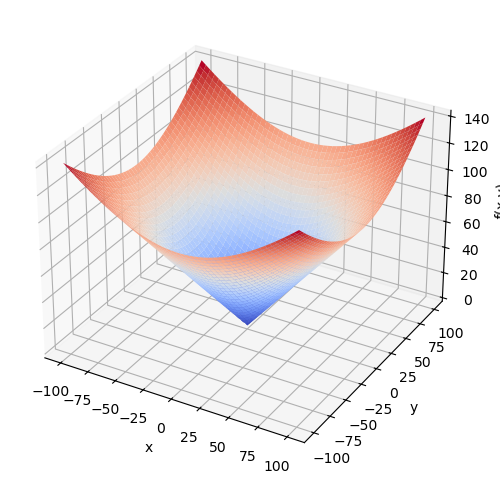

In [59]:
# Definimos la función objetivo
def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

# Generamos vectores que barran todo el dominio
x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

# Evaluamos todos los valores de las variables
x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_[x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

# Representamos los resultados obtenidos
figure_3d = plt.figure(figsize=(8, 6))
ax = figure_3d.add_subplot(111, projection="3d")

ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

In [60]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individuo", list, fitness=creator.FitnessMax)

def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return (-1,)
    res = math.sqrt(x[0] ** 2 + x[1] ** 2)
    return (res,)


def crear_toolbox(n_poblacion):
    toolbox = base.Toolbox()
    toolbox.register("attributo_uniforme", random.uniform, -100, 100)
    toolbox.register("individuo", tools.initRepeat, creator.Individuo, toolbox.attributo_uniforme, n=2)
    toolbox.register("Poblacion", tools.initRepeat, list, toolbox.individuo, n=n_poblacion)
    toolbox.register("evaluate", funcion_objetivo)
    toolbox.register("mate",   tools.cxOnePoint)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
    # mu = Media de la distribución gaussiana para la mutación
    # sigma = Desviación estándar de la distribución gaussiana para la mutación
    # indpb = Probabilidad de mutación por atributo
    toolbox.register("select", tools.selTournament, tournsize=3)
    return toolbox

c:\Users\panch\anaconda3\envs\notebook\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\panch\anaconda3\envs\notebook\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individuo' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [61]:
def main(n_poblacion, ngen):
    random.seed(42) #Semilla del generador de los número pseudoaleatorios
    CXPB, MUTPB, NGEN = 0.5, 0.2, ngen # Probabilidades de cruza, muta y numero de generaciones 
    toolbox = crear_toolbox(n_poblacion) 
    pop = (toolbox.Poblacion()) # generación de la población inicial
    hof = tools.HallOfFame(1) # almacena al mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) # generar las estadísticas de población sobre el fitness 
    stats.register("avg", np.mean) #calcular la media
    stats.register("std", np.std) #desviación estándar típica
    stats.register("min", np.min) #valor mínimo absoluto de la generación 
    stats.register("max", np.max) #valor máximo absoluto de la generación
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple (pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True) 
    return hof, logbook


def plot_evolucion(log, n_poblacion, ngen, ax):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    ax.plot(gen, fit_mins, "b")
    ax.plot(gen, fit_maxs, "r")
    ax.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor="g", alpha=0.2)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.set_ylim([-10, 160])
    ax.set_title(f"Población = {n_poblacion}  |  Generaciones = {ngen}")
    ax.legend(["Min", "Max", "Avg"], loc="lower center")
    ax.grid(True)

In [67]:
configuraciones = [
    (10, 20),
    (30, 20),
    (50, 20),
]

resultados = []
for n_pop, ngen in configuraciones:
    print(f"POBLACIÓN: {n_pop}  |  GENERACIONES: {ngen}\n{'-'*60}")
    hof, log = main(n_pop, ngen)
    print(f"Mejor fitness : {hof[0].fitness.values[0]:.6f}")
    print(f"Mejor individuo: {hof[0]}")
    resultados.append((n_pop, ngen, hof, log))

filas = []
for n, ngen, hof, log in resultados:
    filas.append(
        {
            "Población": n,
            "Generaciones": ngen,
            "Mejor fitness": round(hof[0].fitness.values[0], 4),
            "Mejor x": round(hof[0][0], 4),
            "Mejor y": round(hof[0][1], 4),
            "Avg última gen": round(log.select("avg")[-1], 4),
            "Std última gen": round(log.select("std")[-1], 4),
            "Min última gen": round(log.select("min")[-1], 4),
            "Max última gen": round(log.select("max")[-1], 4),
        }
    )



POBLACIÓN: 10  |  GENERACIONES: 20
------------------------------------------------------------
gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20

In [66]:
# Tabla comparativa de resultados
df = pd.DataFrame(filas)
print("TABLA COMPARATIVA:")
print("-" * 60)
print(df.to_string(index=False))

TABLA COMPARATIVA:
------------------------------------------------------------
 Población  Generaciones  Mejor fitness  Mejor x  Mejor y  Avg última gen  Std última gen  Min última gen  Max última gen
        10            20       136.7789 -94.6928 -98.7002        136.7789          0.0000        136.7789        136.7789
        30            20       140.1008 -99.3464 -98.7853        140.0666          0.1840        139.0760        140.1008
        50            20       140.6766  99.4752 -99.4716        137.8431         19.8347         -1.0000        140.6766


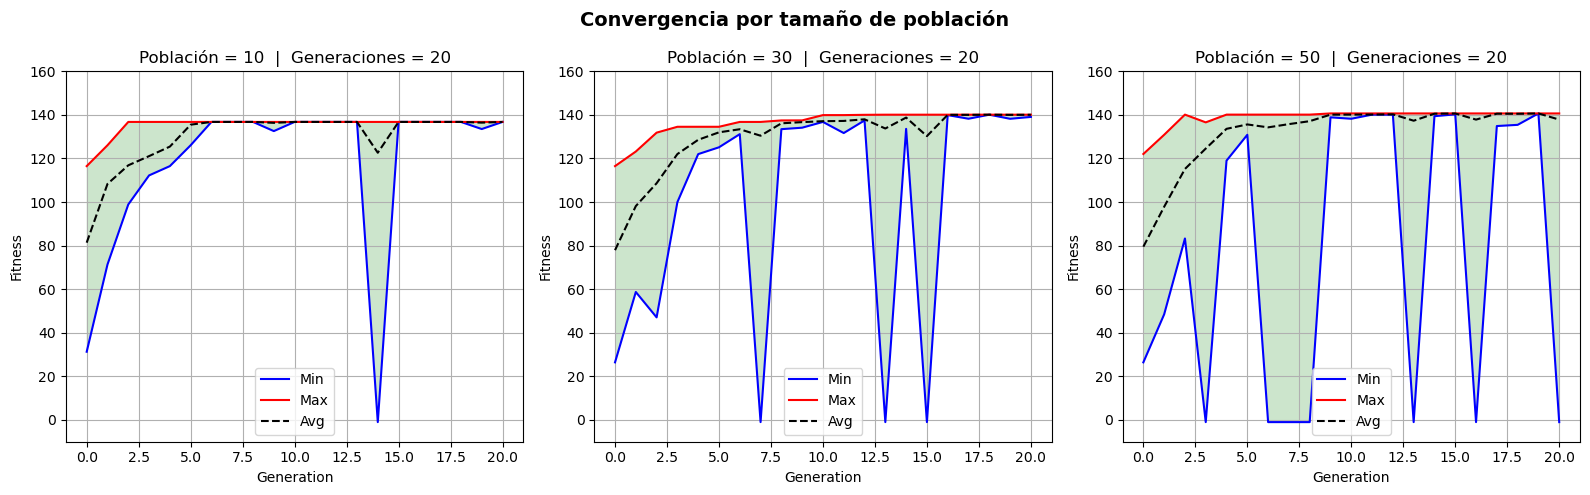

In [64]:
# Gráficas de convergencia por tamaño de población
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Convergencia por tamaño de población", fontsize=14, fontweight="bold")

for ax, (n, ngen, hof, log) in zip(axes, resultados):
    plot_evolucion(log, n, ngen, ax)

plt.tight_layout()
plt.savefig("convergencia_comparativa.png", dpi=300)
plt.show()

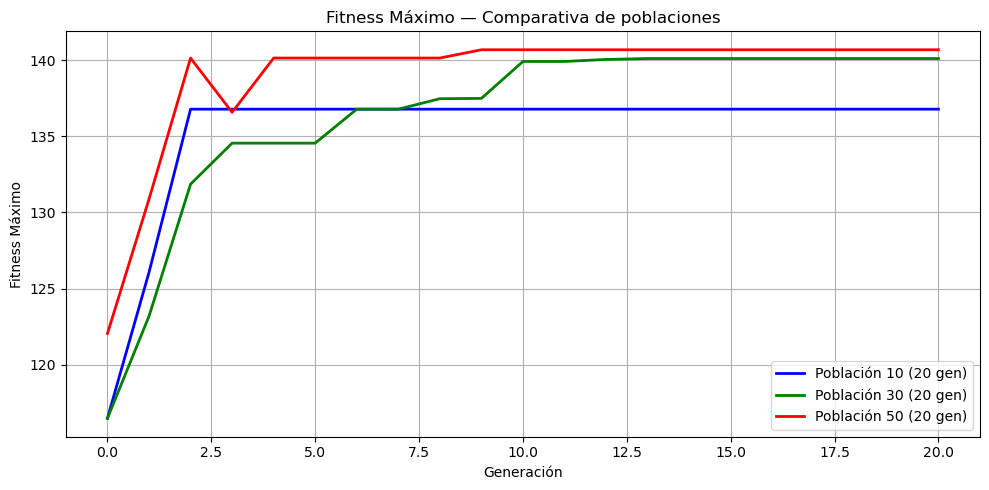

In [65]:
# Fitness máximo por generación para cada configuración
fig2, ax2 = plt.subplots(figsize=(10, 5))
colores = ["blue", "green", "red"]
for (n, ngen, hof, log), color in zip(resultados, colores):
    gen = np.array(log.select("gen"))
    fit_maxs = np.array(log.select("max"), dtype=float)
    ax2.plot(
        gen, fit_maxs, color=color, label=f"Población {n} ({ngen} gen)", linewidth=2
    )

ax2.set_xlabel("Generación")
ax2.set_ylabel("Fitness Máximo")
ax2.set_title("Fitness Máximo — Comparativa de poblaciones")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("comparativa_fitness_max.png", dpi=300)
plt.show()